# DFT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

`I have to hard code FILE_NAME, If you have better suggestion, please tell me.`

gmail address: arvin4943@gmail.com

In [4]:
working_dir = os.getcwd()
FOLDER_NAME = os.path.basename(working_dir)
FILE_NAME = 'fan_v2'

STOCK = 'BTC'
FREQ = '1h'

TRADE_PRICE = 'close'


SEQ_LENGTH = 120
BATCH_SIZE = 16

TRAIN_SPLIT = 0.6
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [5]:
os.chdir(os.path.join('..','data'))
df = pd.read_csv('BTCUSD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [6]:
os.chdir('..')
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [7]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


In [8]:
train = close[:int(np.floor(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:2430, val size:405, test size:1215.


[]

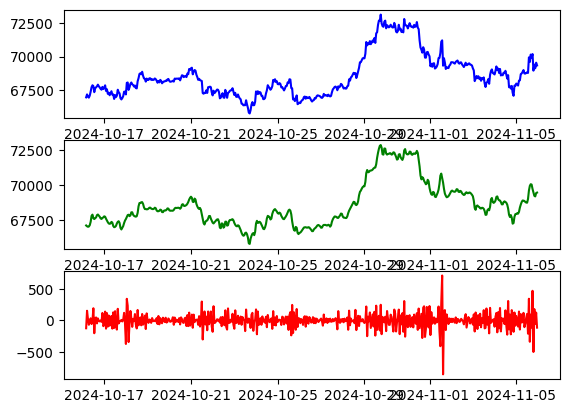

In [21]:
os.getcwd()
os.chdir('..')
os.chdir('denoise')
from dwt import *
os.chdir('..')
os.chdir('FAN')

df[f'smoothed_data_{TRADE_PRICE}'] = wavelet_denoising(df[f'{TRADE_PRICE}'])
df['noise'] = df[f'{TRADE_PRICE}'] - df[f'smoothed_data_{TRADE_PRICE}']

import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8,6))
fig, axs = plt.subplots(3)

axs[0].plot(df[f'{TRADE_PRICE}'].iloc[-500:], color = 'blue')
axs[1].plot(df[f'smoothed_data_{TRADE_PRICE}'].iloc[-500:], color = 'green')
axs[2].plot(df['noise'].iloc[-500:], color = 'red')
plt.plot()

In [22]:
close_denoised = df[f'smoothed_data_{TRADE_PRICE}']
train_denoised = close_denoised[:int(np.floor(TRAIN_SPLIT*len(close_denoised)))]
val_denoised = close_denoised[int(np.ceil(TRAIN_SPLIT*len(close_denoised))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close_denoised) ))]
test_denoised = close_denoised[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close_denoised))):]
assert len(train_denoised) + len(val_denoised) + len(test_denoised) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_denoised.size}, val size:{val_denoised.size}, test size:{test_denoised.size}.')


train size:2430, val size:405, test size:1215.


In [10]:
path = f'./{FILE_NAME}'

try:
    os.mkdir(path)
    print(f"Directory '{path}' created successfully.")
except FileExistsError:
    print(f"Directory '{path}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory './fan_v2' already exists.


In [12]:
import torch

In [13]:
def create_sequence(data, seq_length=SEQ_LENGTH):

    num_seq = len(data) - seq_length

    xs = np.zeros((num_seq,seq_length), dtype=np.int32)
    ys = np.zeros(num_seq, dtype=np.int32)

    for i in range(0,num_seq):
        xs[i,:] = data[i:seq_length+i]
        ys[i] = data[i+seq_length]

    xs = torch.from_numpy(xs).unsqueeze(2)
    ys = torch.from_numpy(ys).unsqueeze(1)

    return xs, ys

xs_train, ys_train = create_sequence(train)
xs_val, ys_val = create_sequence(val)
xs_test, ys_test = create_sequence(test)


In [ ]:
xs_train.shape

In [ ]:
ys_train.shape

In [13]:
def create_dataloader(x, y, batch_size = BATCH_SIZE, shuffle=False):
  dataset = torch.utils.data.TensorDataset(x, y)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return dataloader

In [14]:
train_dataloader = create_dataloader(xs_train, ys_train)
val_dataloader = create_dataloader(xs_val, ys_val)
test_dataloader = create_dataloader(xs_test, ys_test)

In [15]:
x, y = next(iter(train_dataloader))

In [ ]:
print(f'x.shape is:{x.shape}')
print(f'y.shape is:{y.shape}')


np.fft.fftfreq(signal_length, sample_space )

signal_length: the number of samples in your dataset = 120

sample_space: because the distance between data points are the same we consider 1.

## FAN model

In [17]:
def main_freq_part(x, k):
    freq_domain = torch.fft.rfft(x, dim=1)
    magnitudes = torch.abs(freq_domain)
    topk_indices = torch.topk(magnitudes, k , dim=1, largest=True).indices

    mask = torch.ones_like(freq_domain, dtype=torch.complex64)
    for b in range(x.shape[0]):
        mask[b, topk_indices[b], :] = 0

    filtered_freq = freq_domain * mask

    x_res = torch.fft.irfft(filtered_freq, dim=1)
    x_non = x - x_res

    return x_res, x_non

In [ ]:
x_res, x_non = main_freq_part(x, 1)
plt.plot(x_res[0,:,:], color='blue')
plt.plot(x_non[0,:,:], color = 'red')
plt.plot(x[0,:,:], color='green')
plt.legend()
plt.show()

In [19]:
import torch.nn as nn

class MLPfreq(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in):
        super(MLPfreq, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = enc_in
        
        self.model_freq = nn.Sequential(
            nn.Linear(self.seq_len, 64),
            nn.ReLU(),
        )
        
        self.model_all = nn.Sequential(
            nn.Linear(64 + seq_len, 128),
            nn.ReLU(),
            nn.Linear(128, pred_len)
        )


    def forward(self, main_freq, x):
        inp = torch.concat([self.model_freq(main_freq), x], dim=-1)
        return self.model_all(inp)

In [20]:
class FAN(nn.Module):
    def __init__(self, seq_len = SEQ_LENGTH, pred_len = SEQ_LENGTH, enc_in = 1, freq_topk=10):
        super(FAN, self).__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.freq_topk = freq_topk
        self._build_model()
        self.pred_main_freq_signal = None
        self.pred_residual = None

    def _build_model(self):
        self.model_freq = MLPfreq(seq_len=self.seq_len, pred_len = self.pred_len, enc_in = self.enc_in)

    def loss(self, true):
        residual, pred_main = main_freq_part(true, self.freq_topk)
        lf = nn.functional.mse_loss
        return lf(self.pred_main_freq_signal, pred_main) + lf(self.pred_residual, residual)
    
    def normalize(self, input):
        x_non, x_res = main_freq_part(input, self.freq_topk)
        self.pred_main_freq_signal = self.model_freq(x_res.transpose(1,2), input.transpose(1,2)).transpose(1,2)
        return x_non.reshape(input.shape[0],input.shape[1],input.shape[2])
    
    def denormalize(self, x_non):
        self.pred_residual = x_non
        output = self.pred_residual + self.pred_main_freq_signal
        return output.reshape(x_non.shape[0], x_non.shape[1], x_non.shape[2])
        

    def forward(self, batch_x, mode='n'):
        if mode == 'n':
            return self.normalize(batch_x)
        elif mode == 'd':
            return self.denormalize(batch_x)
        else:
            raise ValueError("Mode must be 'n' or 'd'.")



#### Normalize with FAN

In [ ]:
fan_layer = FAN(seq_len=SEQ_LENGTH, pred_len=1, enc_in=1, freq_topk=1)
x_normalized = fan_layer(x,mode='n')
print(f"Normalized Output Shape: {x_normalized.shape}")

x_reconstructed = fan_layer(x_normalized, mode='d')
print(f"Reconstructed Output Shape: {x_reconstructed.shape}")



In [ ]:
plt.plot(x[0,:,:],color = 'blue', label = 'x real')
plt.plot(x_reconstructed[0,:,:].detach().numpy()+x_non[0,:,:].detach().numpy(), 'red', label = 'x reconstructed + x non')
plt.plot(x_reconstructed[0,:,:].detach().numpy(), color = 'green', label='just x reconstructed')
plt.legend()

#### normalization FAN

In [ ]:
x = xs_test[:16,:,:]

freq_domain = torch.fft.rfft(x)

magnitudes = torch.abs(freq_domain)
# print(f'the magnitudes shape is :{magnitudes.shape}')

topk_indices = torch.topk(magnitudes,1 , dim=1, largest=True).indices
print(f'the topk_indices shape is :{topk_indices.shape}')

mask = torch.ones_like(freq_domain, dtype=torch.bool)
# print(f'the mask shape is :{mask.shape}')


for b in range(x.shape[0]):
    mask[b, topk_indices[b], :] = False

filtered_freq = freq_domain * mask
# print(f'the filtered_freq shape is :{filtered_freq.shape}')

stationary_signal = torch.fft.irfft(filtered_freq, SEQ_LENGTH, dim=1)
# print(f'the stationary_signal shape is"{stationary_signal.shape}')

from statsmodels.tsa.stattools import adfuller
p_value_mat = np.zeros((x.shape[0], 2), dtype=np.float32)
for i in range(0,x.shape[0]):
   p_value_mat[i,0] = adfuller(xs_test[i,:,:])[1]
   p_value_mat[i,1] = adfuller(stationary_signal[i,:,:])[1]
print(f'The stationarity index before and after normalization are: {np.mean(p_value_mat, axis=0)}.')

# Models

In [24]:
class FANxLSTMWrapper(nn.Module):
    def __init__(self, fan_layer, input_projection, xlstm_stack, output_projection):
        super().__init__()
        
        self.fan_layer = fan_layer
        self.input_projection = input_projection
        self.xlstm_stack = xlstm_stack
        self.output_projection = output_projection

    def forward(self,x, y=None):

        #x.shape = 16,120,1
        x_normalized = self.fan_layer(x, mode='n')
        # x_normalized.shape = 16,120,1
        x_projected = self.input_projection(x_normalized)
        # x_projected.shape = 16,120,32
        xlstm_output = self.xlstm_stack(x_projected)
        # xlstm_output.shape = 16,120,32
        predictions = self.output_projection(xlstm_output)
        #prediction.shape = 16,120,1
        x_reconstructed = self.fan_layer(predictions, mode='d')
        # x_reconstructd.shape = 16,120,1

        return predictions, x_reconstructed


In [26]:
from IPython.display import clear_output

In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
# from darts import TimeSeries
# import numpy as np

# # -------------------------------------------------------------------------------------------
# # Forecasting metrics
# #
# # https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
# # -------------------------------------------------------------------------------------------

# def _naive_forecasting(actual: np.ndarray, seasonality: int = 1):
#     # Naive forecasting method which just repeats previous samples
#     return actual[:-seasonality]

# def root_mean_squared_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
#     # RMSSE - Root Mean Squared Scaled Error
#     q = mean_squared_error(actual, predicted) / mean_squared_error(actual[seasonality:], _naive_forecasting(actual, seasonality))
#     return np.sqrt(q)

# def mean_absolute_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
#     # MASE - Mean Absolute Scaled Error
#     return mean_absolute_error(actual, predicted) / mean_absolute_error(actual[seasonality:], _naive_forecasting(actual, seasonality))

# def calculate_metrics(actual, prediction, model_name, data_type):
#     # Convert Darts TimeSeries to NumPy arrays if necessary
#     if isinstance(actual, TimeSeries):
#         actual = actual.values().flatten()
#     if isinstance(prediction, TimeSeries):
#         prediction = prediction.values().flatten()

#     # Calculate metrics using scikit-learn functions
#     metrics = {
#         "MAE": mean_absolute_error(actual, prediction),
#         "MSE": mean_squared_error(actual, prediction),
#         "RMSE": root_mean_squared_error(actual, prediction),
#         "RMSSE": root_mean_squared_scaled_error(actual, prediction),
#         "MAPE": mean_absolute_percentage_error(actual, prediction) * 100,
#         "MASE": mean_absolute_scaled_error(actual, prediction),
#         "R2": r2_score(actual, prediction)
#     }

#     for metric_name, metric_value in metrics.items():
#         value_str = f"{metric_value:.2f}"
#         if metric_name == "MAPE":
#             value_str += "%"
#         print(f"{model_name} ({data_type}) | {metric_name}: {value_str}")

#     return metrics

In [14]:
model_name = 'xLSTM_fan'
data_type = 'float32'

In [ ]:
# plt.plot(xs_test[-20:], label='test_y', color='blue')
# plt.plot(test_predictions.cpu()[-20:], label='test_predictions', color='red')
# plt.legend()
# plt.show()

# Results

In [16]:
train_predictions = torch.load(f'{FILE_NAME}/train_predictions.pt', map_location=torch.device('cpu'), weights_only=True)
val_predictions = torch.load(f'{FILE_NAME}/val_predictions.pt', map_location=torch.device('cpu'), weights_only=True)
test_predictions = torch.load(f'{FILE_NAME}/test_predictions.pt', map_location=torch.device('cpu'), weights_only= True)
# fax_xlstm_wrapper = torch.load(f'{FILE_NAME}/fan_xlstm_wrapper.pt', map_location=torch.device('cpu'), weights_only=True)

In [ ]:
test_predictions.shape

In [ ]:
ys_test.shape

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# -------------------------------------------------------------------------------------------
# Predict directions
# -------------------------------------------------------------------------------------------

def calculate_directions(data):
    directions = np.diff(data.squeeze())
    directional_data = np.zeros((directions.size, 2))
    for i, diff in enumerate(directions):
        if diff > 0:
            directional_data[i] = [0, 1]  # Up
        else:
            directional_data[i] = [1, 0]  # Down
    return directional_data

def calculate_movement_metrics(true_labels, predicted_labels, model_name, set_type, data_type):
    if set_type == "Train":
        # Calculate only accuracy for the training set
        accuracy = accuracy_score(true_labels, predicted_labels) * 100
        print(f'{model_name} ({data_type}) | Train Accuracy: {accuracy:.2f}%')

        return {'Train Accuracy': accuracy}

    if set_type == "Val":
        # Calculate only accuracy for the validation set
        accuracy = accuracy_score(true_labels, predicted_labels) * 100
        print(f'{model_name} ({data_type}) | Validation Accuracy: {accuracy:.2f}%')

        return {'Validation Accuracy': accuracy}

    elif set_type == "Test":
        # Calculate metrics for the test set
        accuracy = accuracy_score(true_labels, predicted_labels) * 100
        recall = recall_score(true_labels, predicted_labels, pos_label=1) * 100
        precision_rise = precision_score(true_labels, predicted_labels, pos_label=1) * 100
        precision_fall = precision_score(true_labels, predicted_labels, pos_label=0) * 100
        f1 = f1_score(true_labels, predicted_labels, pos_label=1) * 100

        print(f'{model_name} ({data_type}) | Test Accuracy: {accuracy:.2f}%')
        print(f'{model_name} ({data_type}) | Recall: {recall:.2f}%')
        print(f'{model_name} ({data_type}) | Precision (Rise): {precision_rise:.2f}%')
        print(f'{model_name} ({data_type}) | Precision (Fall): {precision_fall:.2f}%')
        print(f'{model_name} ({data_type}) | F1 Score: {f1:.2f}%')

        # Confusion matrix
        cm = confusion_matrix(true_labels, predicted_labels)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap=plt.cm.Blues, xticklabels=["Down", "Up"], yticklabels=["Down", "Up"], cbar=False)

        # Add percentages
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j + 0.5, i + 0.55, f'\n({cm_norm[i, j]:.2%})',
                         horizontalalignment='center',
                         verticalalignment='center',
                         color='black',
                         fontsize=9)

        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'{model_name} Confusion Matrix ({data_type} Data)')
        plt.show()

        return {
            'Test Accuracy': accuracy,
            'Recall': recall,
            'Precision (Rise)': precision_rise,
            'Precision (Fall)': precision_fall,
            'F1 Score': f1
        }

def evaluate_directional_movement(actual_values_train, backtest_train, actual_values_val, backtest_val, actual_values_test, backtest_test, model_name, data_type, using_darts=True):
    if using_darts:
        train_y = actual_values_train.values()
        train_predictions = backtest_train.values()
        val_y = actual_values_val.values()
        val_predictions = backtest_val.values()
        test_y = actual_values_test.values()
        test_predictions = backtest_test.values()
    else:
        train_y = actual_values_train
        train_predictions = backtest_train
        val_y = actual_values_val
        val_predictions = backtest_val
        test_y = actual_values_test
        test_predictions = backtest_test

    # Calculate directions for training set
    true_directions_train = calculate_directions(train_y)
    predicted_directions_train = calculate_directions(train_predictions)

    # Convert to class labels for training set
    true_labels_train = np.argmax(true_directions_train, axis=1)
    predicted_labels_train = np.argmax(predicted_directions_train, axis=1)

    # Calculate directions for validation set
    true_directions_val = calculate_directions(val_y)
    predicted_directions_val = calculate_directions(val_predictions)

    # Convert to class labels for validation set
    true_labels_val = np.argmax(true_directions_val, axis=1)
    predicted_labels_val = np.argmax(predicted_directions_val, axis=1)

    # Calculate directions for test set
    true_directions_test = calculate_directions(test_y)
    predicted_directions_test = calculate_directions(test_predictions)

    # Convert to class labels for test set
    true_labels_test = np.argmax(true_directions_test, axis=1)
    predicted_labels_test = np.argmax(predicted_directions_test, axis=1)

    # Calculate metrics for training set
    metrics_train = calculate_movement_metrics(true_labels_train, predicted_labels_train, model_name, "Train", data_type)

    # Calculate metrics for validation set
    metrics_val = calculate_movement_metrics(true_labels_val, predicted_labels_val, model_name, "Val", data_type)

    # Calculate metrics for test set
    metrics_test = calculate_movement_metrics(true_labels_test, predicted_labels_test, model_name, "Test", data_type)

    # Combine accuracy into the test metrics dictionary
    metrics_test['Validation Accuracy'] = metrics_val['Validation Accuracy']
    metrics_test['Train Accuracy'] = metrics_train['Train Accuracy']

    return true_labels_test, predicted_labels_test, metrics_test

In [ ]:
print(f'train.shape is: {train[120:].shape}')
print(f'train_predictions is: {train_predictions.shape}')

fan_xlstm (float32) | Train Accuracy: 51.75%
fan_xlstm (float32) | Validation Accuracy: 52.46%
fan_xlstm (float32) | Test Accuracy: 52.01%
fan_xlstm (float32) | Recall: 56.25%
fan_xlstm (float32) | Precision (Rise): 54.27%
fan_xlstm (float32) | Precision (Fall): 49.30%
fan_xlstm (float32) | F1 Score: 55.24%


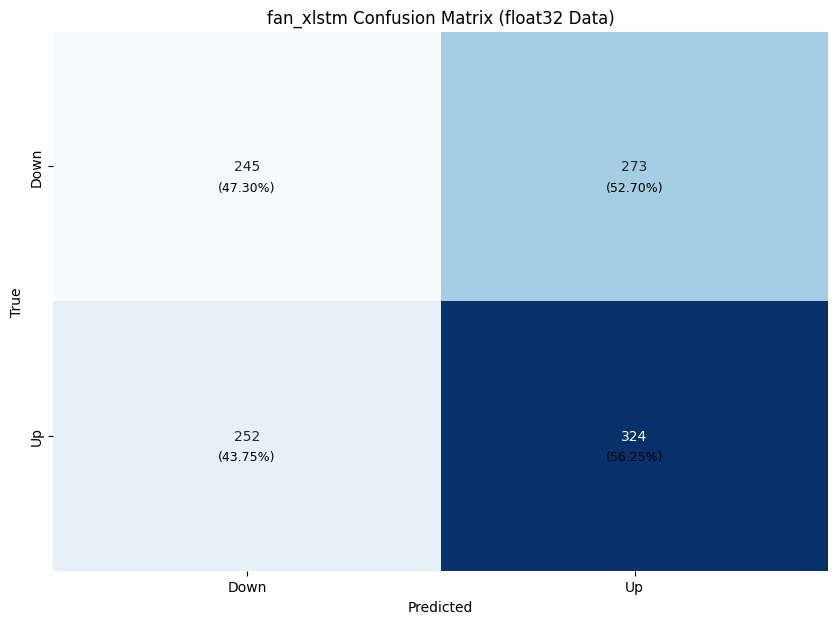

In [23]:
true_labels_test, predicted_labels_test, metrics_test = evaluate_directional_movement(train_denoised[120:], train_predictions, val_denoised[120:], val_predictions, test_denoised[120:], test_predictions, 'fan_xlstm', data_type='float32', using_darts=False )

In [26]:
train_predictions.type

<function Tensor.type>

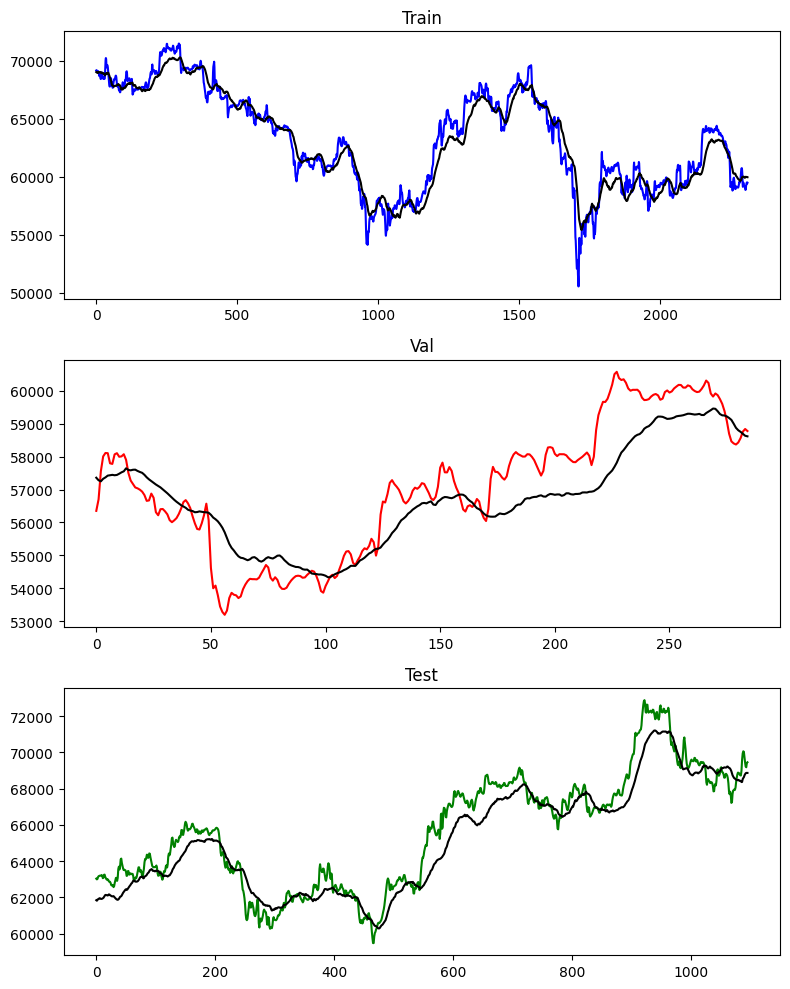

In [29]:
fig, axes = plt.subplots(3,1 , figsize=(8,10))

axes[0].plot(train_denoised[120:].to_numpy(), color='blue')
axes[0].plot(train_predictions, color='black')
axes[0].set_title('Train')

axes[1].plot(val_denoised[120:].to_numpy(), color='red')
axes[1].plot(val_predictions, color = 'black')
axes[1].set_title('Val')

axes[2].plot(test_denoised[120:].to_numpy(), color='green')
axes[2].plot(test_predictions, color='black')
axes[2].set_title('Test')

plt.tight_layout()

plt.show()